<font size =8> Barnacle Detection after multi-step Post-processing</font>


<font size =4>
This experiment investigates progressive fine-tuning a pre-trained YOLOv8 segmentation model across three sequential stages to enhance barnacle detection.

The model will be fine-tuned:

1. On a large dataset of of satellite images of buildings. 
2. Then, on a smaller dataset of polygons that resemble the shape of barnacles
3. Finally, on our custom barnacle dataset for specific task specialization.

This multi-stage approach explores how successive domain adaptation impacts model performance. My hypothesis is that progressive fine-tuning on relevant intermediate datasets will significantly lower the initial loss when training on subsequent stages, indicating improved feature initialization and overall performance.

In [2]:
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import fiftyone as fo 
from fiftyone.core.labels import Detections
import ipywidgets
from PIL import Image
import numpy as np

<font size =6><u>Training Stage 1</u></font>


<font size =4> Firstly, I train the model on bash a dataset of aerial images of building layouts. I do this with the intention of improving the model's campabilities in pixel-wise segmentation. The script for the training process can be found on the Progressivefinetuning.ipynb. The dataset was downloaded from [roboflow](https://universe.roboflow.com/building-1yuss/building-hqjen/dataset/1/download).  

To download the dataset, you will need to have a roboflow account. Once you make an account, follow the steps below: 
1. Open the aforementioned link
2. Press on Download->Download dataset
3. Select the 'Image and Annotation Format' as YOLOv8(or others if you wanna try a different model)
4. Press on the download option you prefer.

<font size =6><u>Training Details</u></font>

<font size =4>Training data = 7739<br>
Val data = 1936<br>
batch size = 16<br>
epochs =20

Below are graphs for the visualization of the training. As you can see, the loss decreases but does not converge. Larger epoch size might lead to convergence but at the same time, might lead to overfitting as well.

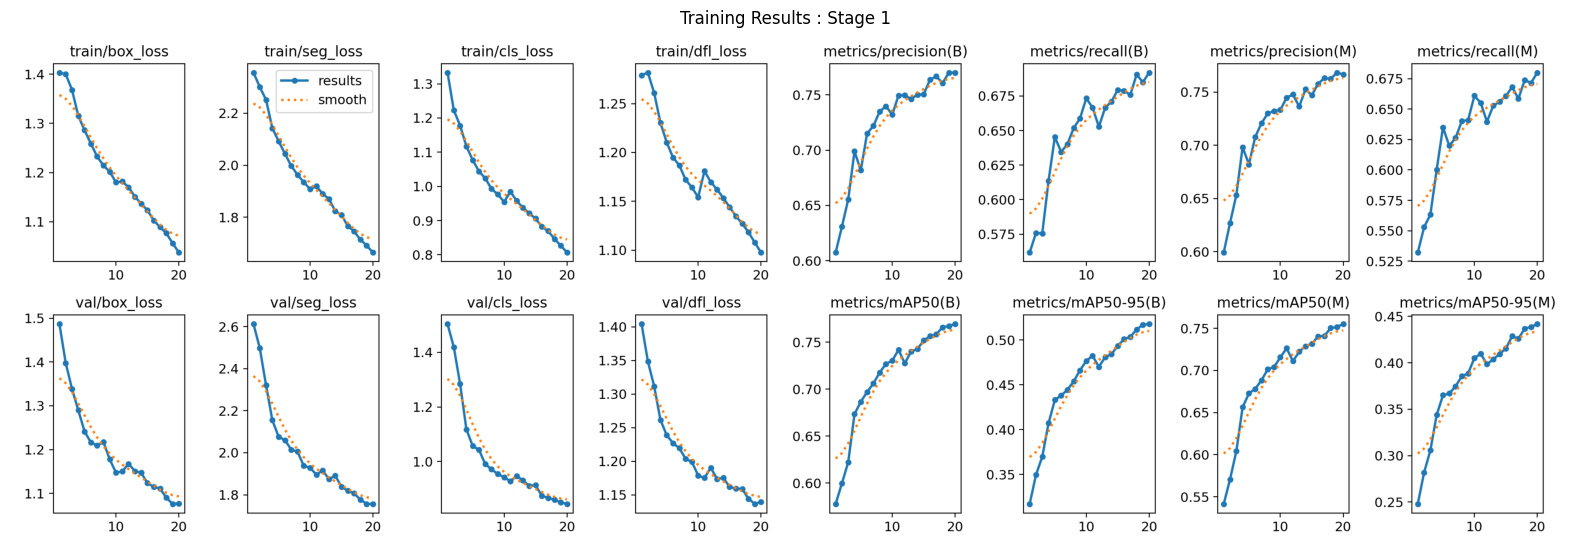

In [10]:
img = np.asarray(Image.open("training_stage_1/results.png"))
plt.figure(figsize=(20,20))
plt.title("Training Results : Stage 1")
plt.axis("off")
plt.imshow(img)
plt.show()


<font size = 6>Training Stage 2</font>

<foint size =4> For this stage, I train the recently trained model on an oilpalm dataset. While this sounds extremely out of context, the annotations show very close resemblance to barnacles. I believe training the model on this image segmentation dataset might lead to improved performances. Like the building outline dataset, this dataset can also be found on [roboflow](https://universe.roboflow.com/testi-vq2kh/polygon-campur/dataset/10#). To download, follow the same steps as above.

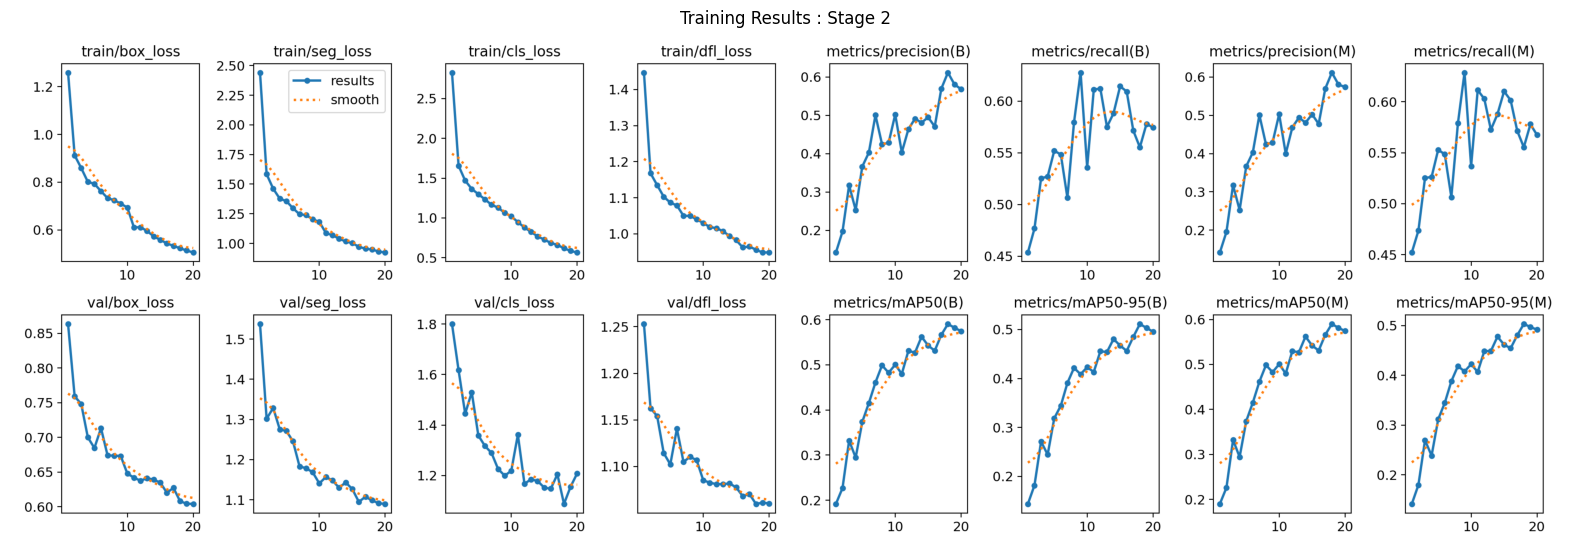

In [12]:
img = np.asarray(Image.open("training_stage_2/results.png"))
plt.figure(figsize=(20,20))
plt.title("Training Results : Stage 2")
plt.axis("off")
plt.imshow(img)
plt.show()


<font size = 4.5> The model converges decreases with epochs completed. Following this training, I will perform a final tuning on the custom dataset that I prepared and examine the changes in performance due to the progressive fine-tuning. While I believe this won't lead to drastic changes as the other model did pretty well just on the custom dataset, any improvement would indicate this approach of training on unrelated datasets can be taken when there is limited data. 

<font size = 6> <u>Creating Fiftyone Dataset to measure performance</u></font>

<font size = 4> Fiftyone is a multimodal data platform for Computer Vision. I came across it as I was looking for ways to assess the performance of the model robustly. I use fiftyone because I had recently used scikit and COCO and wanted to try something new out. I also read that fiftyone lets you visualize the dataset using a GUI which sounded cool. It took me quite some time to get hang of this but I liked it. 

In [18]:
DATASET_NAME = "barnacle"
if fo.dataset_exists(DATASET_NAME):
    print(f"Deleting existing dataset: '{DATASET_NAME}'")
    fo.delete_dataset(DATASET_NAME)
    print(f"Dataset '{DATASET_NAME}' deleted successfully.")
else:
    print(f"Dataset '{DATASET_NAME}' does not exist (or was already deleted).")

Deleting existing dataset: 'barnacle'
Dataset 'barnacle' deleted successfully.


In [19]:
#keeping persistent as false meanns
dataset= fo.Dataset.from_images_dir("images", 
                                    name = "barnacle", 
                                    persistent = False)


 100% |█████████████████████| 2/2 [22.7ms elapsed, 0s remaining, 87.9 samples/s]     


07/26/2025 17:13:30 - INFO - eta.core.utils -    100% |█████████████████████| 2/2 [22.7ms elapsed, 0s remaining, 87.9 samples/s]     


<font size = 5>Adding Ground Truths and Predictions in the dataset 



<font size = 4> In this step, I create ground truth labellings for the fiftyone dataset. To do so, I will be performing Connected Componenets Analysis on the image masks for each sample, iterate through all the detected masks, and create bounding boxes for the masks.These will later be used for accuracy analysis methods like IoU calculation. 

In [20]:
import fiftyone as fo
import fiftyone.utils.data as fou 
import cv2 
import numpy as np 
import os

IMAGE_DIR = "images" 
MASK_DIR = "masks"   

GROUND_TRUTH_FIELD = "ground_truth" 



if GROUND_TRUTH_FIELD not in dataset.get_field_schema():
    print(f"Adding ground truth masks to the '{GROUND_TRUTH_FIELD}' field...")
    
    #manually mapping the images to their masks because only two so convenient
    filename_mapping = {
        "sample_image.png":"mask1.png", 
        "sample_image2.png":"mask2.png"
    }


    for sample in dataset:   #Prepare masks for each image in the dataset
        img_filename = os.path.basename(sample.filepath)
        mask_filename = filename_mapping.get(img_filename) # handles cases where an image might not have a mask
        mask_path = os.path.join(MASK_DIR, mask_filename)

        if not os.path.exists(mask_path):
            print(f"Warning: Mask not found at {mask_path} for {img_filename}. Skipping ground truth for this sample.")
            continue

        # Use cv2.IMREAD_GRAYSCALE to ensure it's loaded as a single channel
        gt_mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        
        if gt_mask_image is None:
            print(f"Error: Could not load mask image from {mask_path}. Skipping ground truth.")
            continue

        # Binarizing
        _, binary_mask = cv2.threshold(gt_mask_image, 1, 255, cv2.THRESH_BINARY)

        # Connected component analysis
        num_labels, labels_img, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, 8, cv2.CV_32S)

        gt_detections = []

        for i in range(1, num_labels):
            # Create a boolean mask for the current instance
            instance_mask = (labels_img == i) 

            y_coords, x_coords = np.where(instance_mask)
            
            # Skip mask if empty 
            if y_coords.size == 0:
                continue

            x_min, x_max = x_coords.min(), x_coords.max()
            y_min, y_max = y_coords.min(), y_coords.max()

            img_height, img_width = gt_mask_image.shape[:2]
            
            bbox_width = max(1, x_max - x_min + 1)
            bbox_height = max(1, y_max - y_min + 1)

            rel_bounding_box = [
                x_min / img_width,
                y_min / img_height,
                bbox_width / img_width,
                bbox_height / img_height
            ]

            cropped_mask = instance_mask[y_min:y_max+1, x_min:x_max+1]

            gt_detections.append(
                fo.Detection(
                    label="barnacle",
                    bounding_box=rel_bounding_box,
                    mask=cropped_mask.astype(bool)  
                )
            )

        sample[GROUND_TRUTH_FIELD] = fo.Detections(detections=gt_detections)
        sample.save()

    print(f"Ground truth masks added to the '{GROUND_TRUTH_FIELD}' field for all samples.")
else:
    print(f"Field '{GROUND_TRUTH_FIELD}' already exists. Skipping ground truth addition.")

print(dataset)
#Sanity Check 
sample = dataset.first()
has_gt = sample.ground_truth is not None and len(sample.ground_truth.detections) > 0
print(f"Sample 1 has ground truth: {has_gt}")
print("-------------------------------------------------------------------------------------------------------------------------------------")


Adding ground truth masks to the 'ground_truth' field...
Ground truth masks added to the 'ground_truth' field for all samples.
Name:        barnacle
Media type:  image
Num samples: 2
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Sample 1 has ground truth: True
-------------------------------------------------------------------------------------------------------------------------------------


<font size =4> Here, I add the predictions made by my model to the dataset. By looping over the images, my model performs SAHI inference on the models, extrats the results, converts it into the format for fiftyone detection objects and saves the results under  "PREDICTIONS_FIELDS" in the dataset 

In [21]:
PREDICTIONS_FIELD= "predictions"
if PREDICTIONS_FIELD not in  dataset.get_field_schema():
    print(f"\nRunning model inference and adding predictions to the '{PREDICTIONS_FIELD}' field...")

    for sample in dataset:
        model_output_preds = sahi_inference(sample.filepath) 

        # Convert raw model output into FiftyOne Detection objects
        fo_predictions = model_output_preds.to_fiftyone_detections()
        sample[PREDICTIONS_FIELD] = fo.Detections(detections=fo_predictions)
        sample.save() # Saving changes 

    print(f"Model predictions added to the 'predictions' field for all samples.")
else:
    print(f"Field 'predictions' already exists. Skipping prediction addition.")


#sanity check
print(dataset)
print(f"Sample 1 has predictions field: {'predictions' in dataset.first().field_names}")
# for intelligibility
print("--------------------------------------------------------------------------------------------------------------------------------------")



Running model inference and adding predictions to the 'predictions' field...
Performing prediction on 49 slices.
Performing prediction on 49 slices.
Model predictions added to the 'predictions' field for all samples.
Name:        barnacle
Media type:  image
Num samples: 2
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    predictions:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Sample 1 has predictions field: True
---------------------------

<font size =4>Run evaluations using the predictions and the ground-truth labels calculated above. Do it for several different IoU values for a more comprehensive analysis 

In [22]:
results = dataset.evaluate_detections(
    PREDICTIONS_FIELD,
    gt_field = GROUND_TRUTH_FIELD, 
    eval_key = "sahi_evaluation", 
    method = "coco", 
    iou = 0.25, # relatively low value
    compute_mAP= True
)

Evaluating detections...


07/26/2025 17:14:35 - INFO - fiftyone.utils.eval.detection -   Evaluating detections...


 100% |█████████████████████| 2/2 [9.7m elapsed, 0s remaining, 0.0 samples/s]   


07/26/2025 17:24:15 - INFO - eta.core.utils -    100% |█████████████████████| 2/2 [9.7m elapsed, 0s remaining, 0.0 samples/s]   


Performing IoU sweep...


07/26/2025 17:24:15 - INFO - fiftyone.utils.eval.coco -   Performing IoU sweep...


 100% |█████████████████████| 2/2 [4.8s elapsed, 0s remaining, 0.4 samples/s]   


07/26/2025 17:24:20 - INFO - eta.core.utils -    100% |█████████████████████| 2/2 [4.8s elapsed, 0s remaining, 0.4 samples/s]   


In [28]:
results.print_metrics()
plot = results.plot_confusion_matrix(classes=["barnacle"])
plot.show()

07/26/2025 17:59:01 - INFO - choreographer.utils._tmpfile -   TemporaryDirectory.cleanup() worked.
07/26/2025 17:59:01 - INFO - choreographer.utils._tmpfile -   shutil.rmtree worked.


accuracy   0.42
precision  0.49
recall     0.76
fscore     0.59
support    2267


FigureWidget({
    'data': [{'mode': 'markers',
              'opacity': 0.1,
              'type': 'scatter',
              'uid': '9223b4df-606c-4044-8db3-35c5529f0e82',
              'x': {'bdata': 'AAEAAQ==', 'dtype': 'i1'},
              'y': {'bdata': 'AAABAQ==', 'dtype': 'i1'}},
             {'colorscale': [[0.0, 'rgb(255,245,235)'], [0.125,
                             'rgb(254,230,206)'], [0.25, 'rgb(253,208,162)'],
                             [0.375, 'rgb(253,174,107)'], [0.5, 'rgb(253,141,60)'],
                             [0.625, 'rgb(241,105,19)'], [0.75, 'rgb(217,72,1)'],
                             [0.875, 'rgb(166,54,3)'], [1.0, 'rgb(127,39,4)']],
              'hoverinfo': 'skip',
              'showscale': False,
              'type': 'heatmap',
              'uid': '676c23b4-72c6-4d09-9aed-209ae855ebd6',
              'z': {'bdata': 'JgcAALwGHwI=', 'dtype': 'i2', 'shape': '2, 2'},
              'zmax': np.int64(1830),
              'zmin': 0},
             {'color

In [7]:
def sahi_inference(image_filepath): 
    
    result = get_sliced_prediction(
        'images/sample_image.png',
        model, slice_height=256,
        slice_width=256,
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.4,
        overlap_height_ratio=0.2,
        postprocess_class_agnostic = True,
        overlap_width_ratio=0.2,
        )
    return result